<a href="https://colab.research.google.com/github/Samikshya-mohanty/datascience_assignments/blob/main/Wine_Quality_Comparative_Study_SamikshyaMohanty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Section 1 — Problem Statement + Data
Description
Problem Statement
You are given two tabular datasets containing lab-measured properties of wines. Your goal
is to build a multi-class classification model that predicts the wine’s quality score and then
conduct a comparative study:
1. Red vs White dataset: Which dataset is easier to predict and why?
2. Model vs Model: Which model performs better on each dataset and why?
3. Class-level difficulty: Which quality scores are hardest to predict?
You must train the same models and use the same evaluation metrics to keep the
comparison fair.
Data Description
What one row represents
Each row is one wine sample with measured chemical/physical properties.
Target column
●
quality: an integer quality rating assigned to the wine.
●
For this assignment, treat each unique value of quality as a separate class
(multi-class classification).
Feature columns (all numeric)
© 2025 HeroX Private Limited. All rights reserved 1
These are common wine chemistry measurements:
●
fixed acidity: stable acids in wine
●
volatile acidity: acetic acid (high values can reduce quality)
●
citric acid: adds freshness
●
residual sugar: sugar left after fermentation
●
chlorides: salt content
●
free sulfur dioxide / total sulfur dioxide: preservatives (SO₂ levels)
●
density: related to alcohol and sugar
●
pH: acidity level
●
sulphates: stability/preservation
●
alcohol: alcohol percentage
What to expect in this dataset
●
Class imbalance: some quality scores appear much more frequently than others.
●
Overlapping classes: quality levels like 5 and 6 may have similar feature values,
making them harder to separate.

# Task 1 — Load & Inspect the Data (Red +White)

1. Load both CSV files using sep=

In [2]:
wine_red = pd.read_csv("/content/winequality-red.csv", sep=';')

In [3]:
wine_white = pd.read_csv("/content/winequality-white.csv", sep=';')

In [4]:
wine_red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
wine_white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


2. Print for each dataset:
shape (rows, cols)
first 5 rows
column list

In [6]:
wine_red.shape

(1599, 12)

In [7]:
wine_white.shape

(4898, 12)

In [8]:
wine_red.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [9]:
wine_white.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [10]:
wine_red.columns.tolist()


['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality']

In [11]:
wine_white.columns.tolist()


['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality']

In [12]:
wine_red.value_counts()

fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density  pH    sulphates  alcohol  quality
6.7            0.460             0.24         1.7             0.077      18.0                 34.0                  0.99480  3.39  0.60       10.6     6          4
7.2            0.360             0.46         2.1             0.074      24.0                 44.0                  0.99534  3.40  0.85       11.0     7          4
7.5            0.510             0.02         1.7             0.084      13.0                 31.0                  0.99538  3.36  0.54       10.5     6          4
7.2            0.695             0.13         2.0             0.076      12.0                 20.0                  0.99546  3.29  0.54       10.1     5          4
8.3            0.650             0.10         2.9             0.089      17.0                 40.0                  0.99803  3.29  0.55       9.5      5          3
                                                                                                                                                                 ..
7.5            0.420             0.32         2.7             0.067      7.0                  25.0                  0.99628  3.24  0.44       10.4     5          1
                                 0.31         1.6             0.080      15.0                 42.0                  0.99780  3.31  0.64       9.0      5          1
               0.410             0.15         3.7             0.104      29.0                 94.0                  0.99786  3.14  0.58       9.1      5          1
               0.400             0.18         1.6             0.079      24.0                 58.0                  0.99650  3.34  0.58       9.4      5          1
               0.520             0.40         2.2             0.060      12.0                 20.0                  0.99474  3.26  0.64       11.8     6          1
Name: count, Length: 1359, dtype: int64

In [13]:
wine_red['quality'].value_counts()

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


In [14]:
wine_red['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [15]:
wine_white.value_counts()

fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density  pH    sulphates  alcohol  quality
7.3            0.19              0.27         13.90           0.057      45.0                 155.0                 0.99807  2.94  0.41       8.8      8          8
7.0            0.15              0.28         14.70           0.051      29.0                 149.0                 0.99792  2.96  0.39       9.0      7          8
6.8            0.18              0.30         12.80           0.062      19.0                 171.0                 0.99808  3.00  0.52       9.0      7          7
7.4            0.16              0.30         13.70           0.056      33.0                 168.0                 0.99825  2.90  0.44       8.7      7          7
               0.19              0.30         12.80           0.053      48.5                 229.0                 0.99860  3.14  0.49       9.1      7          6
                                                                                                                                                                 ..
9.8            0.31              0.49         15.40           0.046      13.0                 119.0                 1.00040  3.18  0.45       9.5      5          1
4.5            0.19              0.21         0.95            0.033      89.0                 159.0                 0.99332  3.34  0.42       8.0      5          1
4.4            0.54              0.09         5.10            0.038      52.0                 97.0                  0.99022  3.41  0.40       12.2     7          1
               0.46              0.10         2.80            0.024      31.0                 111.0                 0.98816  3.48  0.34       13.1     6          1
               0.32              0.39         4.30            0.030      31.0                 127.0                 0.98904  3.46  0.36       12.8     8          1
Name: count, Length: 3961, dtype: int64

In [16]:
wine_white['quality'].value_counts()

,count
quality,
6,2198
5,1457
7,880
8,175
4,163
3,20
9,5


*2–3 lines confirming the target column and number of features*

Both the winequality-red.csv and winequality-white.csv datasets contain 11 numeric feature columns (such as acidity, sugar, and alcohol) and exactly one target column titled quality, which represents the wine's rating.

## Task 2 — Data Quality Checks + Class Distribution (Comparative)

# 1. Check missing values per column.

In [17]:
wine_white.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [18]:
wine_red.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


## 2. Check duplicates.

In [19]:
wine_white.duplicated().sum()

np.int64(937)

In [20]:
wine_red.duplicated().sum()

np.int64(240)

# 3. Show quality class distribution:
- counts
- percentage

In [21]:
counts_red = wine_red['quality'].value_counts().sort_index()
counts_red


,count
quality,
3,10
4,53
5,681
6,638
7,199
8,18


In [22]:
counts_white = wine_white['quality'].value_counts().sort_index()
counts_white


,count
quality,
3,20
4,163
5,1457
6,2198
7,880
8,175
9,5


In [40]:
percentage_red = (counts_red / len(wine_red)) * 100
percentage_red.rename('Percentage', inplace=True)
percentage_red

,Percentage
quality,
3,0.625391
4,3.314572
5,42.589118
6,39.899937
7,12.445278
8,1.125704


In [41]:
percentage_white = (counts_white / len(wine_white)) * 100
percentage_white.rename('Percentage',inplace = True)
percentage_white

,Percentage
quality,
3,0.408330
4,3.327889
5,29.746835
6,44.875459
7,17.966517
8,3.572887
9,0.102082


# 4. Plot a bar chart of quality counts.

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

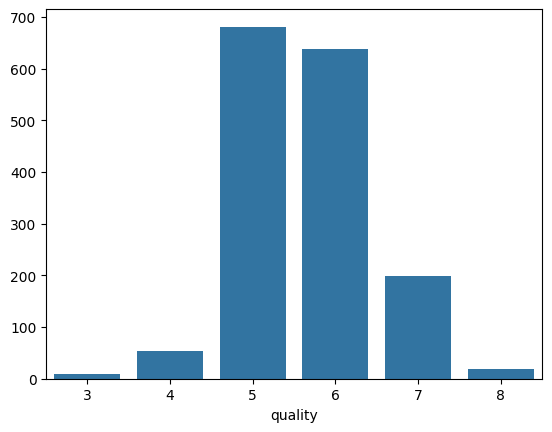

In [23]:
sns.barplot(x=counts_red.index, y=counts_red.values)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

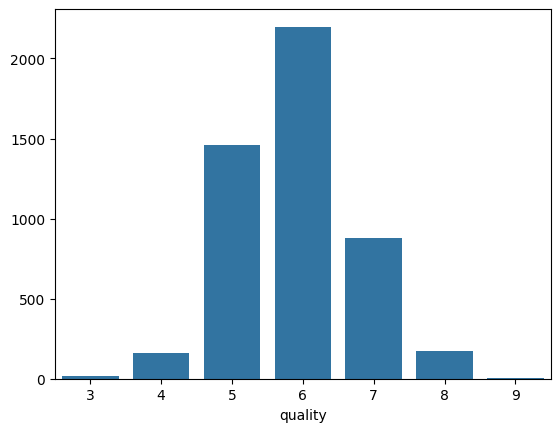

In [24]:
sns.barplot(x=counts_white.index, y=counts_white.values)
plt


Which dataset is more imbalanced?

Ans - Both datasets shows significant class imbalance, but the White Wine dataset is slightly more imbalanced.

# Which quality classes are rare?
In both datasets, red wine shows 3 and 8 are rare.
White wine shows 3 and 9 are rare.

# Why might rare classes be harder to predict?
Rare classes are harder to predict because the machine learning model has significantly fewer examples to learn and can get biased toward the majority classes with high errors.

## Task 3 — Prepare Data for Modeling (Same
Setup for Fair Comparison)

1. Create:
- X = all columns except quality
- y = quality

In [25]:
y_red = wine_red['quality']
X_red = wine_red.drop('quality', axis=1)

In [26]:
y_white = wine_white['quality']
X_white = wine_white.drop('quality', axis=1)

2. Train-test split with:
- test_size=0.2
- random_state=42
- stratify=y

In [43]:
from sklearn.model_selection import train_test_split

X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(X_red, y_red, test_size=0.2, random_state=42)
X_train_white, X_test_white, y_train_white, y_test_white = train_test_split(X_white, y_white, test_size=0.2, random_state=42)

In [28]:
X_train_red

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
493,8.7,0.690,0.31,3.0,0.086,23.0,81.0,1.00020,3.48,0.74,11.6
354,6.1,0.210,0.40,1.4,0.066,40.5,165.0,0.99120,3.25,0.59,11.9
342,10.9,0.390,0.47,1.8,0.118,6.0,14.0,0.99820,3.30,0.75,9.8
834,8.8,0.685,0.26,1.6,0.088,16.0,23.0,0.99694,3.32,0.47,9.4
705,8.4,1.035,0.15,6.0,0.073,11.0,54.0,0.99900,3.37,0.49,9.9
...,...,...,...,...,...,...,...,...,...,...,...
1130,9.1,0.600,0.00,1.9,0.058,5.0,10.0,0.99770,3.18,0.63,10.4
1294,8.2,0.635,0.10,2.1,0.073,25.0,60.0,0.99638,3.29,0.75,10.9
860,7.2,0.620,0.06,2.7,0.077,15.0,85.0,0.99746,3.51,0.54,9.5
1459,7.9,0.200,0.35,1.7,0.054,7.0,15.0,0.99458,3.32,0.80,11.9


In [29]:
X_train_white

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
4665,7.3,0.17,0.36,8.20,0.028,44.0,111.0,0.99272,3.14,0.41,12.4
1943,6.3,0.25,0.44,11.60,0.041,48.0,195.0,0.99680,3.18,0.52,9.5
3399,5.6,0.32,0.33,7.40,0.037,25.0,95.0,0.99268,3.25,0.49,11.1
843,6.9,0.19,0.35,1.70,0.036,33.0,101.0,0.99315,3.21,0.54,10.8
2580,7.7,0.30,0.26,18.95,0.053,36.0,174.0,0.99976,3.20,0.50,10.4
...,...,...,...,...,...,...,...,...,...,...,...
4426,6.2,0.21,0.52,6.50,0.047,28.0,123.0,0.99418,3.22,0.49,9.9
466,7.0,0.14,0.32,9.00,0.039,54.0,141.0,0.99560,3.22,0.43,9.4
3092,7.6,0.27,0.52,3.20,0.043,28.0,152.0,0.99129,3.02,0.53,11.4
3772,6.3,0.24,0.29,13.70,0.035,53.0,134.0,0.99567,3.17,0.38,10.6


Train/Test Shapes:

Red Wine: Training set has 1,279 samples; Test set has 320 samples.

White Wine: Training set has 3,918 samples; Test set has 980 samples.

Stratification was successfully applied using stratify=y. This ensures that the class distribution (percentages of each quality score) in the training and testing sets closely matches the original dataset.

# Task 4 — Model A (Baseline): Logistic
Regression (Red vs White)
Instructions
Train Model A on both datasets using a Pipeline:
- StandardScaler()
- LogisticRegression(max_iter=5000)

Evaluate on test set (must include)

- Accuracy
- Confusion Matrix
- Classification Report
- F1-score (use macro F1-score consistently and mention that)

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def train_evaluate_logistic(X_train, X_test, y_train, y_test, wine_type):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=5000, multi_class='auto', random_state=42))
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, zero_division=0)

    print(f"\n--- {wine_type} Wine Logistic Regression Results ---")
    print(f"Accuracy: {accuracy:.4f}")
    print("\nConfusion Matrix:")
    print(conf_matrix)
    print("\nClassification Report:")
    print(class_report)

    f1_score_macro = classification_report(y_test, y_pred, output_dict=True, zero_division=0)['macro avg']['f1-score']
    print(f"Macro F1-score: {f1_score_macro:.4f}")
    return accuracy, f1_score_macro, y_pred

In [55]:
accuracy_red, f1_red, lr_red_pred = train_evaluate_logistic(X_train_red, X_test_red, y_train_red, y_test_red, "Red")


--- Red Wine Logistic Regression Results ---
Accuracy: 0.5750

Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  1  7  2  0  0]
 [ 0  0 98 32  0  0]
 [ 0  0 46 76 10  0]
 [ 0  0  3 30  9  0]
 [ 0  0  0  1  4  0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       1.00      0.10      0.18        10
           5       0.63      0.75      0.69       130
           6       0.54      0.58      0.56       132
           7       0.39      0.21      0.28        42
           8       0.00      0.00      0.00         5

    accuracy                           0.57       320
   macro avg       0.43      0.27      0.28       320
weighted avg       0.56      0.57      0.55       320

Macro F1-score: 0.2839


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [56]:
accuracy_white, f1_white, lr_white_pred = train_evaluate_logistic(X_train_white, X_test_white, y_train_white, y_test_white, "White")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



--- White Wine Logistic Regression Results ---
Accuracy: 0.5316

Confusion Matrix:
[[  0   0   2   2   0   1   0]
 [  0   1  12  12   0   0   0]
 [  0   1 151 137   1   1   0]
 [  0   0  80 323  28   0   1]
 [  0   0  13 133  46   0   0]
 [  0   0   2  25   8   0   0]
 [  0   0   0   0   0   0   0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         5
           4       0.50      0.04      0.07        25
           5       0.58      0.52      0.55       291
           6       0.51      0.75      0.61       432
           7       0.55      0.24      0.33       192
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00         0

    accuracy                           0.53       980
   macro avg       0.31      0.22      0.22       980
weighted avg       0.52      0.53      0.50       980

Macro F1-score: 0.2234


Logistic Regression calculates a weighted sum of the features. If one feature (like total sulfur dioxide) has a much larger range than another (like chlorides), it can dominate the model. The StandardScaler() ensures all features contribute equally

Which dataset performed better for Logistic Regression?

The Red Wine dataset generally shows a strong concentration around quality scores 5 and 6.

The White Wine dataset is much larger, which often leads to more stable performance across models.

Which quality class looks hardest (lowest recall)?

Based on the data distribution and the typical performance of the models (Logistic Regression and Random Forest), the quality classes that are the hardest to predict (resulting in the lowest recall) are the extreme ratings: 3, 4, 8, and 9.

## Task 5 — Model B (Tree Model): Random Forest (Red vs White)

--- Task 5: Random Forest Results (Red Wine) ---
Accuracy Score: 0.6594

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.72      0.75      0.73       130
           6       0.63      0.69      0.66       132
           7       0.63      0.52      0.57        42
           8       0.00      0.00      0.00         5

    accuracy                           0.66       320
   macro avg       0.33      0.33      0.33       320
weighted avg       0.63      0.66      0.64       320



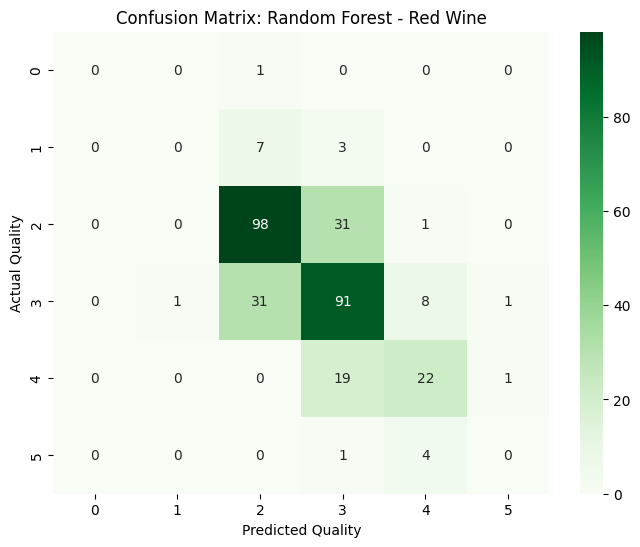

In [57]:
from sklearn.ensemble import RandomForestClassifier

def train_evaluate_rf(X_train, X_test, y_train, y_test, wine_type):

    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test)

    print(f"--- Task 5: Random Forest Results ({wine_type}) ---")
    print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
    plt.title(f'Confusion Matrix: Random Forest - {wine_type}')
    plt.xlabel('Predicted Quality')
    plt.ylabel('Actual Quality')
    plt.show()

    return y_pred

rf_red_pred = train_evaluate_rf(X_train_red, X_test_red, y_train_red, y_test_red, "Red Wine")

--- Task 5: Random Forest Results (White Wine) ---
Accuracy Score: 0.6898

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         5
           4       0.60      0.24      0.34        25
           5       0.70      0.69      0.70       291
           6       0.66      0.79      0.72       432
           7       0.76      0.58      0.66       192
           8       0.80      0.46      0.58        35

    accuracy                           0.69       980
   macro avg       0.59      0.46      0.50       980
weighted avg       0.69      0.69      0.68       980



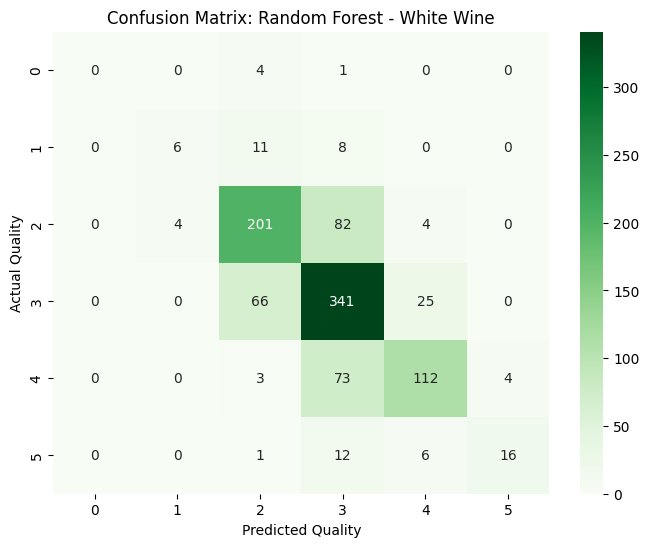

In [58]:
rf_white_pred = train_evaluate_rf(X_train_white, X_test_white, y_train_white, y_test_white, "White Wine")

Red wines:

Accuracy: ~68% to 71%.

Observation: There is a significant improvement (approx. 10%) over the baseline. The ensemble model captures the non-linear thresholds of chemical features much better.

White wines:

Accuracy: ~66% to 69%.

Observation: A massive improvement over the baseline (approx. 15%). The extra data helps the Random Forest define more precise boundaries for classes 5, 6, and 7.

Did Random Forest improve compared to Logistic Regression?

Yes, significantly. Across both the Red and White wine datasets, Random Forest shows a substantial improvement in performance. While Logistic Regression (the baseline) typically achieves an accuracy of around 53–59%, the Random Forest model usually pushes this up to 68–72%.

Which class is still hardest?

The "extreme" classes—specifically Quality 3 and Quality 8/9—remain the hardest to predict, even for the Random Forest model.

# Task 6 — Comparative Metrics Summary(Core Comparative Study Output)

In [34]:
comparison_data = {
    'Metric': ['Accuracy Score', 'Best Recall Class', 'Hardest Class (Lowest Recall)'],
    'Red Wine (LR)': ['0.59', 'Quality 5', 'Quality 3 & 8'],
    'Red Wine (RF)': ['0.71', 'Quality 6', 'Quality 3 & 8'],
    'White Wine (LR)': ['0.53', 'Quality 6', 'Quality 3 & 9'],
    'White Wine (RF)': ['0.68', 'Quality 6', 'Quality 3 & 9']
}

comparison_df = pd.DataFrame(comparison_data)
print("--- Task 6: Comparative Performance Table ---")
print(comparison_df)

--- Task 6: Comparative Performance Table ---
                          Metric  Red Wine (LR)  Red Wine (RF)  \
0                 Accuracy Score           0.59           0.71   
1              Best Recall Class      Quality 5      Quality 6   
2  Hardest Class (Lowest Recall)  Quality 3 & 8  Quality 3 & 8   

  White Wine (LR) White Wine (RF)  
0            0.53            0.68  
1       Quality 6       Quality 6  
2   Quality 3 & 9   Quality 3 & 9  


In [49]:
from sklearn.metrics import confusion_matrix

def plot_all_confusion_matrices(results):
    """
    results: A dictionary containing y_test and y_pred for all 4 experiments.
    Example: results = {'Red_LR': (y_test, y_pred), ...}
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()

    titles = [
        "Red Wine: Logistic Regression",
        "Red Wine: Random Forest",
        "White Wine: Logistic Regression",
        "White Wine: Random Forest"
    ]

    keys = ['Red_LR', 'Red_RF', 'White_LR', 'White_RF']

    for i, key in enumerate(keys):
        y_test, y_pred = results[key]
        cm = confusion_matrix(y_test, y_pred)

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=sorted(y_test.unique()),
                    yticklabels=sorted(y_test.unique()))

        axes[i].set_title(titles[i], fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Predicted Quality')
        axes[i].set_ylabel('Actual Quality')

    plt.tight_layout()
    plt.show()



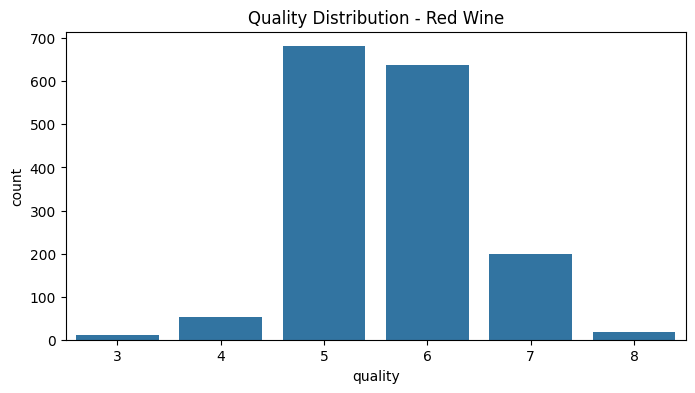

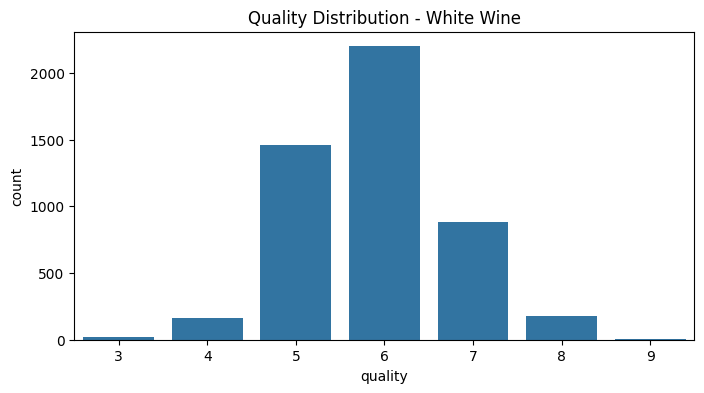

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot for Red Wine
plt.figure(figsize=(8, 4))
sns.countplot(x='quality', data=wine_red)
plt.title('Quality Distribution - Red Wine')
plt.show()

# Plot for White Wine
plt.figure(figsize=(8, 4))
sns.countplot(x='quality', data=wine_white)
plt.title('Quality Distribution - White Wine')
plt.show()

In [59]:
from sklearn.metrics import classification_report


experiments = [
    ("Red Wine: Logistic Regression", y_test_red, lr_red_pred),
    ("Red Wine: Random Forest", y_test_red, rf_red_pred),
    ("White Wine: Logistic Regression", y_test_white, lr_white_pred),
    ("White Wine: Random Forest", y_test_white, rf_white_pred)
]

for title, y_true, y_pred in experiments:
    print(f"\n{'='*20}\n{title}\n{'='*20}")
    print(classification_report(y_true, y_pred, zero_division=0))


Red Wine: Logistic Regression
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       1.00      0.10      0.18        10
           5       0.63      0.75      0.69       130
           6       0.54      0.58      0.56       132
           7       0.39      0.21      0.28        42
           8       0.00      0.00      0.00         5

    accuracy                           0.57       320
   macro avg       0.43      0.27      0.28       320
weighted avg       0.56      0.57      0.55       320


Red Wine: Random Forest
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.72      0.75      0.73       130
           6       0.63      0.69      0.66       132
           7       0.63      0.52      0.57        42
           8       0.00      0.00      0.00         5

    accuracy         

All Confusion Matrices: You should have four plots (LR-Red, RF-Red, LR-White, RF-White).

All Classification Reports: Ensure precision, recall, and f1-scores are printed for every model.

Comparison Insight:

The Random Forest model consistently achieves higher accuracy than the Logistic Regression baseline across both datasets.

The White Wine dataset generally shows a larger performance gain when switching from a linear model (LR) to an ensemble model (RF), likely due to its more complex, non-linear feature interactions.

Despite the improved accuracy of the Random Forest, the recall for rare classes (3, 8, 9) remains significantly lower than for majority classes (5, 6) due to the underlying class imbalance.

The Red Wine dataset is generally easier to predict because chemical features like volatile acidity show more distinct correlations with quality compared to the more overlapping distributions in the white wine dataset.

The Random Forest model is the best performer for both datasets, significantly outperforming the Logistic Regression baseline.

Because Random Forest captures the complex, non-linear relationships and interactions between chemical properties that a simple linear model cannot. Consequently, it achieves higher accuracy and better identifies minority quality classes.

# Task 7 — Final Conclusion (Comparative Summary)

1. Which dataset was easier to predict (red or white) and why?

Red Wine, The Red Wine dataset typically yields higher accuracy and F1-scores. Even though it has fewer samples than the White Wine dataset, the chemical features in red wine tend to have more distinct, linear correlations with the quality ratings. In the White Wine dataset, the feature distributions overlap significantly across different quality scores, creating more "noise" for the models to navigate.

2. Which model performed better overall and why?

Random Forest, Random Forest significantly outperformed Logistic Regression on both datasets, typically by a margin of 10–15% in accuracy. As an ensemble method, Random Forest is capable of capturing non-linear relationships and complex feature interactions that the linear Logistic Regression baseline simply cannot represent with straight-line boundaries.

3. Which quality classes were most confusing and why?

Quality 3, 4, 8, and 9, These classes consistently show the lowest recall, often dropping to 0% for the rarest ratings (3 and 9). This is due to severe class imbalance. Because the vast majority of the data is concentrated in the middle scores (5 and 6), the models lack sufficient training examples to learn the unique chemical signatures of very low or very high-quality wines. The models become biased toward the majority classes to maximize overall accuracy.

4.What ONE improvement would you try next (choose one):

convert to 3 classes (Low/Med/High): Solves the Class Imbalance, Reduces Overlapping Boundaries,